Коэффициент корреляции Пирсона: 0.749
t-статистика: 7.413, p-value: 0.00000

Уравнение регрессии Y на X: Y = 0.854X + 0.310
Уравнение регрессии X на Y: X = 0.657Y + 2.251
Проверка с использованием scipy: Y = 0.854X + 0.310


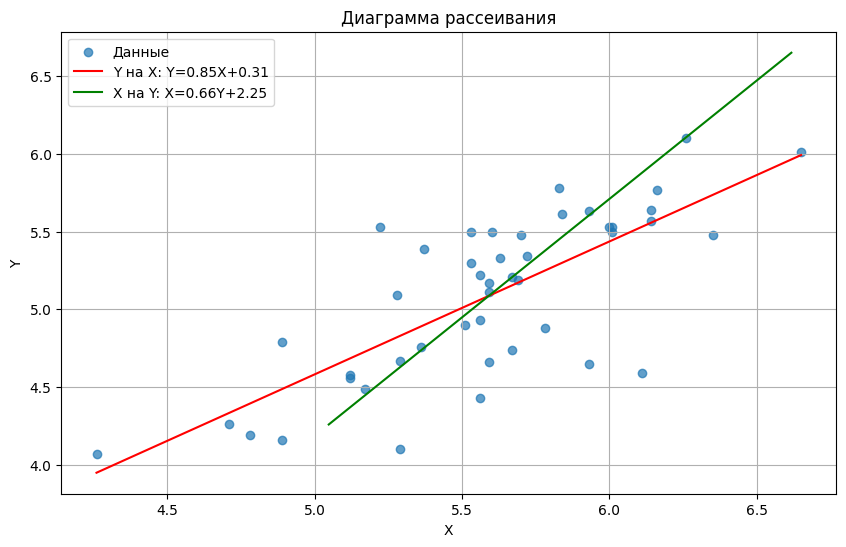


Оценка дисперсии ошибок s^2: 0.128
Коэффициент детерминации R^2: 0.561

Доверительные интервалы для параметров регрессии (95.0%):
a: [-0.994, 1.614], b: [0.622, 1.087]

Доверительный интервал для sigma^2: [0.087, 0.206]


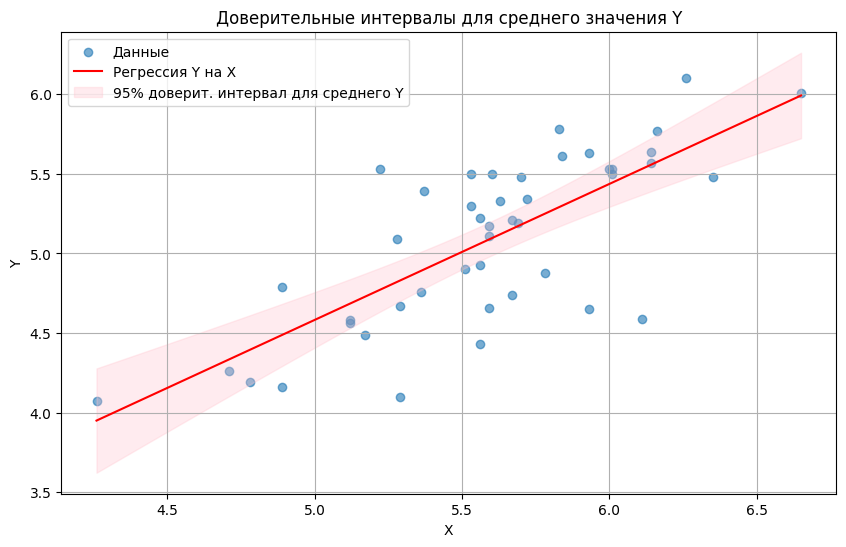


F-статистика: 54.959, p-value: 0.00000
Регрессия статистически значима на уровне 0.05

Результаты регрессии:
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.561
Model:                            OLS   Adj. R-squared:                  0.551
Method:                 Least Squares   F-statistic:                     54.96
Date:                Wed, 30 Apr 2025   Prob (F-statistic):           3.26e-09
Time:                        14:31:05   Log-Likelihood:                -16.585
No. Observations:                  45   AIC:                             37.17
Df Residuals:                      43   BIC:                             40.78
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm

# Данные пользователя (X и Y)
data = [
    [5.29, 4.1],
    [4.26, 4.07],
    [4.89, 4.16],
    [6.35, 5.48],
    [5.84, 5.61],
    [5.37, 5.39],
    [5.72, 5.34],
    [6.11, 4.59],
    [5.7, 5.48],
    [5.36, 4.76],
    [5.69, 5.19],
    [5.67, 4.74],
    [5.78, 4.88],
    [5.93, 4.65],
    [5.17, 4.49],
    [5.6, 5.5],
    [5.59, 5.11],
    [5.56, 4.93],
    [5.56, 5.22],
    [5.12, 4.58],
    [6.16, 5.77],
    [6.01, 5.5],
    [5.22, 5.53],
    [5.51, 4.9],
    [4.78, 4.19],
    [6.01, 5.53],
    [5.59, 4.66],
    [5.12, 4.56],
    [4.89, 4.79],
    [5.59, 5.17],
    [5.93, 5.63],
    [6.0, 5.53],
    [5.67, 5.21],
    [6.65, 6.01],
    [5.63, 5.33],
    [6.26, 6.1],
    [5.29, 4.67],
    [4.71, 4.26],
    [5.28, 5.09],
    [6.14, 5.64],
    [5.53, 5.3],
    [5.56, 4.43],
    [6.14, 5.57],
    [5.83, 5.78],
    [5.53, 5.5]
]

# Разделение на X и Y
X = np.array([row[0] for row in data])
Y = np.array([row[1] for row in data])

# 1) Диаграмма рассеивания и коэффициент корреляции Пирсона
plt.figure(figsize=(10, 6))
plt.scatter(X, Y, alpha=0.7, label='Данные')
plt.title('Диаграмма рассеивания')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True)

r = np.corrcoef(X, Y)[0, 1]
print(f"Коэффициент корреляции Пирсона: {r:.3f}")

n = len(X)
t_stat = r * np.sqrt((n - 2) / (1 - r**2))
p_value = 2 * (1 - stats.t.cdf(np.abs(t_stat), n - 2))
print(f"t-статистика: {t_stat:.3f}, p-value: {p_value:.5f}")

# 2) Уравнения линейной регрессии Y на X и X на Y
x_mean = np.mean(X)
y_mean = np.mean(Y)

cov_xy = np.cov(X, Y)[0, 1]
var_x = np.var(X, ddof=1)
var_y = np.var(Y, ddof=1)

a1 = cov_xy / var_x
b1 = y_mean - a1 * x_mean
print(f"\nУравнение регрессии Y на X: Y = {a1:.3f}X + {b1:.3f}")

a2 = cov_xy / var_y
b2 = x_mean - a2 * y_mean
print(f"Уравнение регрессии X на Y: X = {a2:.3f}Y + {b2:.3f}")

# Проверка с использованием scipy
slope_y_on_x, intercept_y_on_x, r_value, p_value_scipy, std_err = stats.linregress(X, Y)
print(f"Проверка с использованием scipy: Y = {slope_y_on_x:.3f}X + {intercept_y_on_x:.3f}")

# 3) Графики регрессионных прямых
x_values = np.array([min(X), max(X)])
y_regression = a1 * x_values + b1
x_regression = a2 * x_values + b2

plt.plot(x_values, y_regression, color='red', label=f'Y на X: Y={a1:.2f}X+{b1:.2f}')
plt.plot(x_regression, x_values, color='green', label=f'X на Y: X={a2:.2f}Y+{b2:.2f}')
plt.legend()
plt.show()

# Часть 2: Оценка качества регрессионной модели

# Добавление константы для регрессии
X_with_const = sm.add_constant(X)
model = sm.OLS(Y, X_with_const).fit()

# 1) Оценка дисперсии ошибок s^2
residuals = model.resid
s2 = np.sum(residuals**2) / (n - 2)
print(f"\nОценка дисперсии ошибок s^2: {s2:.3f}")

# 2) Коэффициент детерминации R^2
R2 = model.rsquared
print(f"Коэффициент детерминации R^2: {R2:.3f}")

# 3) Доверительные интервалы для параметров регрессии
confidence = 0.95
params_ci = model.conf_int(alpha=1 - confidence)
print(f"\nДоверительные интервалы для параметров регрессии ({confidence * 100}%):")
print(f"a: [{params_ci[0][0]:.3f}, {params_ci[0][1]:.3f}], b: [{params_ci[1][0]:.3f}, {params_ci[1][1]:.3f}]")

# 4) Доверительный интервал для дисперсии ошибок sigma^2
chi2_lower = stats.chi2.ppf((1 + confidence)/2, n - 2)
chi2_upper = stats.chi2.ppf((1 - confidence)/2, n - 2)
ci_sigma2_lower = (n - 2) * s2 / chi2_lower
ci_sigma2_upper = (n - 2) * s2 / chi2_upper
print(f"\nДоверительный интервал для sigma^2: [{ci_sigma2_lower:.3f}, {ci_sigma2_upper:.3f}]")

# 5) Доверительные интервалы для среднего значения Y при x0
x0 = np.linspace(min(X), max(X), 100)
pred = model.get_prediction(sm.add_constant(x0))
pred_summary = pred.summary_frame(alpha=0.05)

plt.figure(figsize=(10, 6))
plt.scatter(X, Y, alpha=0.6, label='Данные')
plt.plot(x0, pred_summary['mean'], color='red', label='Регрессия Y на X')
plt.fill_between(x0, pred_summary['mean_ci_lower'], pred_summary['mean_ci_upper'], color='pink', alpha=0.3, label='95% доверит. интервал для среднего Y')
plt.title('Доверительные интервалы для среднего значения Y')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True)
plt.show()

# 6) Проверка значимости регрессии
f_stat = model.fvalue
p_value_f = model.f_pvalue
print(f"\nF-статистика: {f_stat:.3f}, p-value: {p_value_f:.5f}")
if p_value_f < 0.05:
    print("Регрессия статистически значима на уровне 0.05")
else:
    print("Регрессия не значима на уровне 0.05")

# Вывод результатов регрессии
print("\nРезультаты регрессии:")
print(model.summary())